# RAFT Large optical-flow playbook

This notebook runs the smallest RAFT Large path: two consecutive frames from a video, then a 2×2 composite of those frames, the flow color wheel, and a vector overlay.

It assumes a ROCm virtualenv from `setup_venv.sh` already exists. This repository has no `.devcontainer/`.

## What this notebook demonstrates

RAFT Large predicts optical flow between frame N and frame N+1. `infer_optical_flow.py` chooses the run from the output extension:

- an image extension processes one pair (`--frame` and the next frame);
- a video extension processes every consecutive pair and writes an H.264 MP4.

The smoke run below writes `outputs/playbook/flow_pair.png`. If that image appears, the venv, the weight download, and the sample video path are working.

Weights are not stored in the repo. The first run downloads torchvision's RAFT Large checkpoint.

## Assumptions

- Python environment: `.venv-rocm-10.0.0` if present, otherwise `.venv-rocm-7.2.1`. Create one with `bash setup_venv.sh 10.0.0` or `bash setup_venv.sh 7.2.1`.
- An AMD GPU is expected. The script falls back to CPU and prints a warning.
- `FAST_MODE = True` turns `torch.compile` off and runs one pair. That is the colleague check. The full video, with compile left on, is the optional cell at the end.
- The script sets the GPU power state to `performance` and may prompt for sudo when the current state differs.
- A `+rocm10` build sets `MIOPEN_FIND_MODE=1` inside the script. Exporting that variable first overrides it.

## Paths and configuration

Edit this cell for a different video, frame, or precision. Paths are relative to the repository root.

Expected result: the cell prints the chosen Python and creates `outputs/playbook/`.

In [ ]:
import subprocess
import sys
from pathlib import Path

def find_repo_root(start: Path) -> Path:
    """Jupyter sets the kernel cwd to notebooks/, so walk upward."""
    for candidate in [start, *start.parents]:
        if (candidate / "infer_optical_flow.py").exists():
            return candidate
    raise FileNotFoundError(
        "Could not find infer_optical_flow.py above the working directory "
        f"{start}. Open this notebook from the repository."
    )

REPO_ROOT = find_repo_root(Path.cwd())

VIDEO = REPO_ROOT / "Geisskopf_Gap_Jump.mp4"
FRAME = 156  # 5.2 s at 30 fps; the pair is this frame and the next one
RESIZE = "376x672"
PARAM_DTYPE = "fp16"
FAST_MODE = False
OUTPUT_DIR = REPO_ROOT / "outputs" / "playbook"
SMOKE_PNG = OUTPUT_DIR / "flow_pair.png"
FULL_VIDEO = OUTPUT_DIR / "optical_flow.mp4"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def rocm_python() -> Path:
    for name in (".venv-rocm-10.0.0", ".venv-rocm-7.2.1"):
        candidate = REPO_ROOT / name / "bin" / "python"
        if candidate.exists():
            return candidate
    return Path(sys.executable)

PYTHON = rocm_python()

def run(cmd: list[str], cwd: Path | None = None) -> None:
    print("$", " ".join(map(str, cmd)))
    subprocess.run(cmd, cwd=cwd, check=True)

print("python:", PYTHON)
print("video:", VIDEO)
print("fast mode:", FAST_MODE)
print("output dir:", OUTPUT_DIR)


## Environment sanity checks

This cell asks the selected interpreter for the PyTorch build and whether a GPU is visible. It does not load the model.

Expected result: a `+rocm` version string and `cuda_available True` on the iGPU. `cuda_available` is the HIP path in a ROCm build.

In [ ]:
if not PYTHON.exists():
    raise FileNotFoundError(
        f"Missing interpreter: {PYTHON}\n"
        "Create a venv with: bash setup_venv.sh 10.0.0"
    )

run([
    str(PYTHON),
    "-c",
    (
        "import torch; "
        "print('torch', torch.__version__); "
        "print('hip', torch.version.hip); "
        "print('cuda_available', torch.cuda.is_available()); "
        "print('device', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'cpu')"
    ),
])


## Input preparation

The documented sample is `Geisskopf_Gap_Jump.mp4` in the repository root. MP4 files are gitignored, so a fresh clone does not contain one. Point `VIDEO` at any OpenCV-readable clip.

Expected result: the cell prints the path and stops with `FileNotFoundError` when the file is absent.

The short pair starts at `FRAME` 156, about 5.2 seconds into the 30 fps sample. The script also reads the next frame. To use your own clip, change `VIDEO` and `FRAME` in the configuration cell.

In [ ]:
if not VIDEO.exists():
    raise FileNotFoundError(
        f"Missing input video: {VIDEO}\n"
        "Place an MP4 in the repository root or set VIDEO in the configuration cell."
    )
print("input ok:", VIDEO)


## Minimal smoke run

Purpose: prove the container-or-venv, the weight download, and one forward pass.

Equivalent command when `FAST_MODE` is true:

```bash
python infer_optical_flow.py \
  --video Geisskopf_Gap_Jump.mp4 \
  --frame 156 \
  --output outputs/playbook/flow_pair.png \
  --compile False \
  --param_dtype fp16 \
  --resize 376x672
```

Expected output: a log line `Saved  : .../outputs/playbook/flow_pair.png`, plus a one-pair summary with flow magnitude. The first run can spend a minute downloading RAFT Large weights. Compile stays off in fast mode so this check does not wait for a HIP graph.

In [ ]:
compile_flag = "False" if FAST_MODE else "True"
run([
    str(PYTHON),
    "infer_optical_flow.py",
    "--video", str(VIDEO),
    "--frame", str(FRAME),
    "--output", str(SMOKE_PNG),
    "--compile", compile_flag,
    "--param_dtype", PARAM_DTYPE,
    "--resize", RESIZE,
], cwd=REPO_ROOT)


## Result visualization

The PNG is a 2×2 composite:

| Top-left | Top-right | Bottom-left | Bottom-right |
|----------|-----------|-------------|--------------|
| Frame N | Frame N+1 | Flow color wheel | Vector field overlay |

The color wheel encodes direction. Brightness encodes speed. A camera pan is a fairly uniform color. A moving object is a distinct colored region. A stationary camera often looks noisy because RAFT reports sub-pixel sensor and compression motion.

Expected result: the composite appears under this cell, and the path is printed.

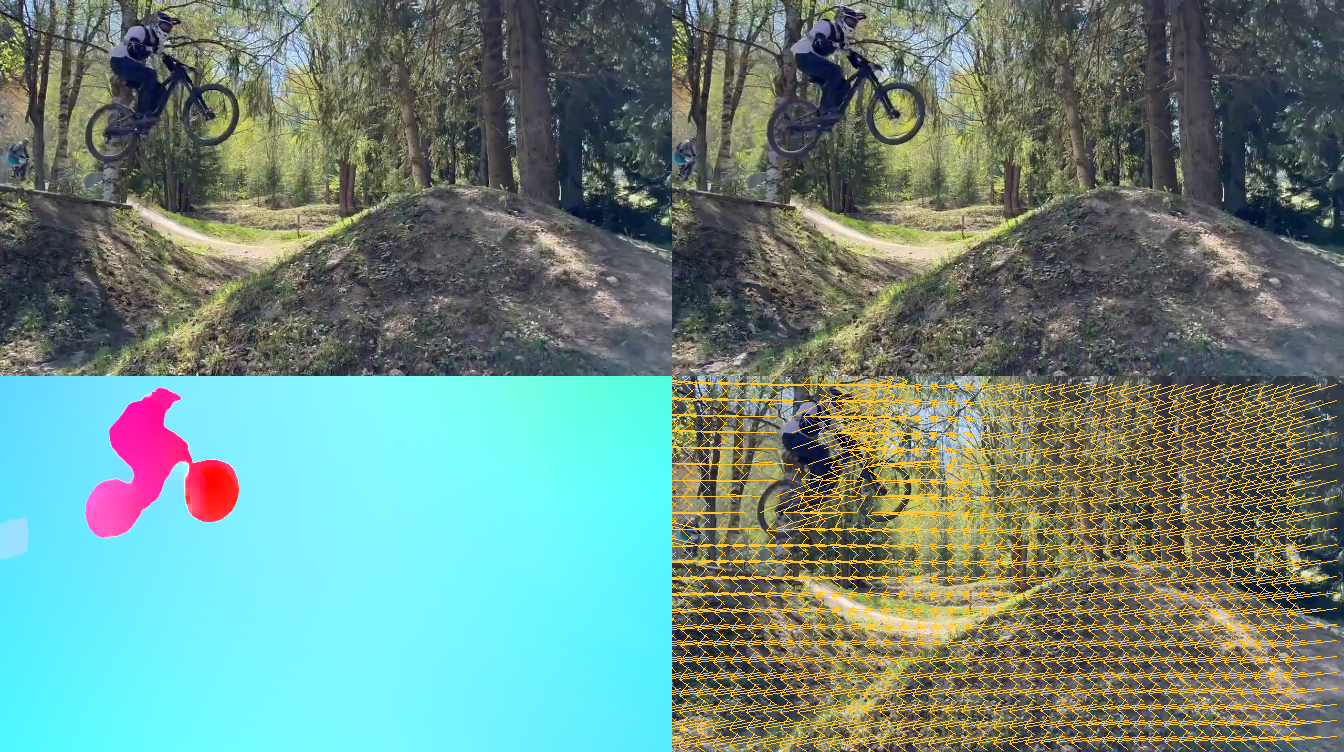

In [5]:
from IPython.display import Image, display

if not SMOKE_PNG.exists():
    raise FileNotFoundError(f"Smoke output was not written: {SMOKE_PNG}")
print("saved:", SMOKE_PNG)
display(Image(filename=str(SMOKE_PNG)))


## How to adapt the demo

- Another clip: set `VIDEO` to that file. Keep it somewhere readable; do not commit proprietary video.
- Another moment: set `FRAME` to the first index of the pair you care about.
- Native resolution: set `RESIZE` to `"none"`. The script then rounds each side down to a multiple of 8, with a floor of 128.
- Precision: `PARAM_DTYPE` is `fp16`, `bf16`, or `fp32`. fp16 is the measured default. bf16 is less accurate on this model because the GRU accumulates small coordinate deltas.
- The timed default path: set `FAST_MODE = False` and run the next cell. That processes the whole video with `torch.compile` in `reduce-overhead` mode and writes `outputs/playbook/optical_flow.mp4`.

There is no local checkpoint path to edit. torchvision downloads RAFT Large on first use.

## Optional full-video run

Skipped while `FAST_MODE` is true. On the 672×376 fp16 path this is about 26 ms per pair on ROCm 10.0.0 after compile warmup, so a short clip finishes in well under a minute once the graph exists. Warmup itself is longer.

Expected output when enabled: `Saved  : .../outputs/playbook/optical_flow.mp4` and a summary line with average milliseconds per pair.

In [ ]:
if FAST_MODE:
    print("FAST_MODE is true; skipping the whole-video run.")
    print("Set FAST_MODE = False in the configuration cell to write", FULL_VIDEO)
else:
    run([
        str(PYTHON),
        "infer_optical_flow.py",
        "--video", str(VIDEO),
        "--output", str(FULL_VIDEO),
        "--param_dtype", PARAM_DTYPE,
        "--resize", RESIZE,
    ], cwd=REPO_ROOT)
    print("saved:", FULL_VIDEO)


## Watch the video

Plays `outputs/playbook/optical_flow.mp4` in the notebook. Run the full-video cell first. The player embeds the MP4 in the cell output, because a `/files/` link does not load inside JupyterLab.

Expected result: a looping player of the 2×2 composite. The clip is about 6 seconds. Re-running this cell reads the file again; it does not rerun inference.

In [ ]:
from IPython.display import Video, display

if not FULL_VIDEO.exists():
    raise FileNotFoundError(
        f"No video at {FULL_VIDEO}.\n"
        "Set FAST_MODE = False and run the full-video cell."
    )
print("playing:", FULL_VIDEO)
display(Video(
    filename=str(FULL_VIDEO),
    embed=True,
    width=960,
    html_attributes="controls autoplay loop",
))


## Troubleshooting

- **Missing video.** The cell above `Minimal smoke run` raises `FileNotFoundError`. Set `VIDEO`.
- **Missing venv.** `bash setup_venv.sh 10.0.0` or `bash setup_venv.sh 7.2.1`, then pick that interpreter in the configuration cell.
- **Sudo prompt.** The script writes the AMD `power_dpm_state` node when it is not already `performance`.
- **`hip_utils.so: failed to map segment`.** `/tmp` is mounted `noexec`. The inference script points `TRITON_CACHE_DIR` and `TORCHINDUCTOR_CACHE_DIR` at `~/.cache` before importing torch. That directory must be writable by your user.
- **`miopenStatusUnknownError`.** See [docs/rocm_issues.md](../docs/rocm_issues.md). On a `+rocm10` build the script sets `MIOPEN_FIND_MODE=1`. An exported value wins over that default.
- **No GPU line.** The script prints `WARNING: No GPU detected` and continues on CPU.

Issue log: [docs/rocm_issues.md](../docs/rocm_issues.md).